<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Error_Bars_in_ggplot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Visualizing Uncertainty: Mastering Error Bars in ggplot2**

### নোটবুক পরিচিতি (Metadata)
- Aim: আর (R) এবং ggplot2 ব্যবহার করে ডেটার গড় (Mean) এবং বিচ্যুতি (Standard Deviation) ভিজ্যুয়ালাইজ করা।
- Dataset: ToothGrowth (গিনিপিগের দাঁতের বৃদ্ধির ওপর ভিটামিন-সি এর প্রভাব)।
- Key Learnings: ডেটা সামারাইজেশন (summarise), স্ট্যান্ডার্ড ডেভিয়েশন গণনা, এবং geom_errorbar এর সঠিক প্রয়োগ।
- Goal: ডট প্লট এবং বার চার্টে এরর বার যোগ করে ডেটার নির্ভরযোগ্যতা প্রদর্শন করা।

### কেন এরর বার (Error Bar) ব্যবহার করবেন?
শুধুমাত্র গড় (Mean) দেখালে অনেক সময় ডেটার প্রকৃত চিত্র বোঝা যায় না। এরর বার আমাদের বলে দেয় যে ডেটা পয়েন্টগুলো গড় থেকে কতটা ছড়িয়ে আছে। এটি মূলত তিনটি বিষয় নির্দেশ করে:
- ১. ডেটার ভ্যারিয়েবিলিটি (Variability)।
- ২. মেজারমেন্ট এরর (Measurement Error)।
- ৩. কনফিডেন্স ইন্টারভ্যাল (Confidence Interval)।

### ১. এনভায়রনমেন্ট এবং থিম সেটআপ
গ্রাফগুলোকে প্রফেশনাল লুক দেওয়ার জন্য আমরা শুরুতেই একটি ক্লিন থিম সেট করে নিচ্ছি।

In [1]:
library(tidyverse)

# গ্লোবাল থিম সেটআপ
theme_set(theme_classic() +
            theme(panel.grid.major = element_blank(),
                  plot.title = element_text(face = "bold", size = 14)))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### ২. ডেটা প্রিপারেশন (Calculating Statistics)
এরর বার আঁকার আগে আমাদের প্রতিটি গ্রুপের জন্য গড় ($\bar{x}$) এবং স্ট্যান্ডার্ড ডেভিয়েশন ($\sigma$) বের করে নিতে হবে।

In [2]:
# শুধু "VC" (Vitamin C) সাপ্লিমেন্টের ডেটা নিয়ে কাজ করা
stats_data <- ToothGrowth %>%
  filter(supp == "VC") %>%
  mutate(dose = as.factor(dose)) %>%
  group_by(dose) %>%
  summarise(Mean_length = mean(len),
            Sd_length = sd(len))

# ক্যালকুলেটেড ডেটা দেখে নেওয়া
print(stats_data)

# A tibble: 3 × 3
  dose  Mean_length Sd_length
  <fct>       <dbl>     <dbl>
1 0.5          7.98      2.75
2 1           16.8       2.52
3 2           26.1       4.80


গাণিতিক লজিক: এখানে আমরা এরর বারের লিমিট সেট করব এভাবে:
$$ymin = Mean\_length - Sd\_length$$
$$ymax = Mean\_length + Sd\_length$$

### ৩. ডট প্লট উইথ এরর বার (Point-Range Plot)
এটি বড় আকারের ডট এবং এরর বার ব্যবহার করে ডেটার ট্রেন্ড দেখানোর একটি আধুনিক পদ্ধতি।

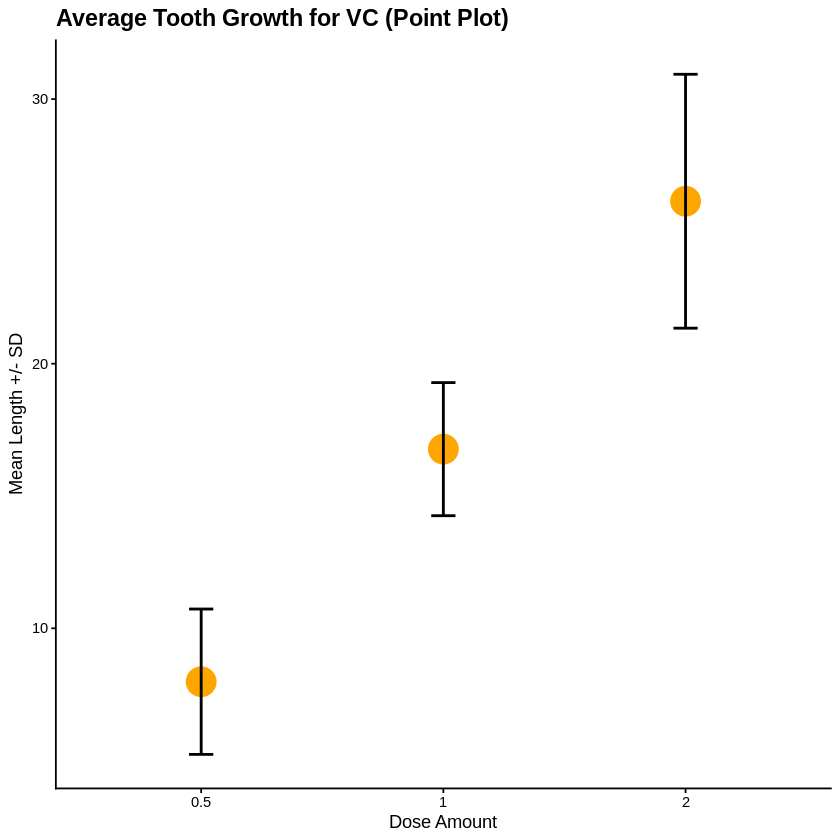

In [3]:
stats_data %>%
  ggplot(aes(dose, Mean_length)) +
  geom_point(size = 8, colour = "orange") + # বড় আকারের ডট
  geom_errorbar(aes(ymin = Mean_length - Sd_length,
                    ymax = Mean_length + Sd_length),
                width = 0.1, # এরর বারের চওড়া নিয়ন্ত্রণ
                linewidth = 0.8) +
  labs(title = "Average Tooth Growth for VC (Point Plot)",
       x = "Dose Amount",
       y = "Mean Length +/- SD")

### ৪. অল্টারনেটিভ: বার চার্ট উইথ এরর বার
ট্রেডিশনাল সায়েন্টিফিক পেপারে বার চার্টের ওপর এরর বার দেওয়ার পদ্ধতিটি বেশি জনপ্রিয়।

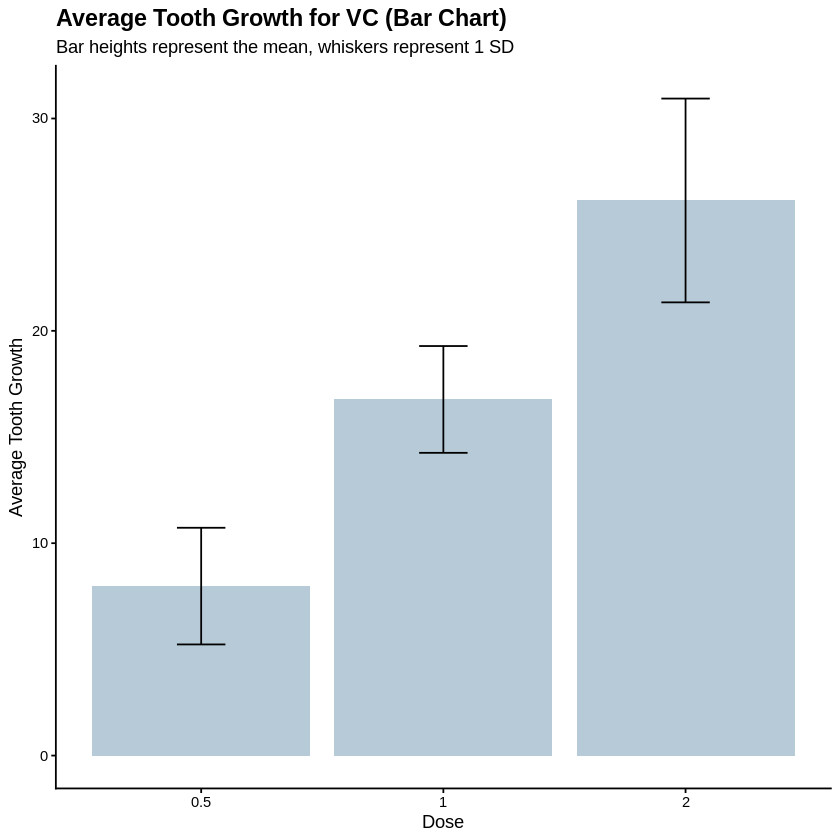

In [4]:
stats_data %>%
  ggplot(aes(dose, Mean_length)) +
  geom_bar(stat = "identity", fill = "#97B3C6", alpha = 0.7) +
  geom_errorbar(aes(ymin = Mean_length - Sd_length,
                    ymax = Mean_length + Sd_length),
                width = 0.2,
                color = "black") +
  labs(title = "Average Tooth Growth for VC (Bar Chart)",
       subtitle = "Bar heights represent the mean, whiskers represent 1 SD",
       x = "Dose",
       y = "Average Tooth Growth")

**সতর্কতা:** বার চার্টে এরর বার ব্যবহারের সময় alpha কমিয়ে দেওয়া ভালো, যাতে এরর বারের কালো রেখাগুলো স্পষ্টভাবে বোঝা যায়।

#### এক নজরে আপনার শেখা টুলকিট (Cheat Sheet):
- summarise(): এরর বারের জন্য প্রয়োজনীয় স্ট্যাটিস্টিকস তৈরি করে।
- geom_errorbar(): ভিজ্যুয়াল অনিশ্চয়তা যোগ করে।
- ymin ও ymax: এরর বারের সর্বনিম্ন ও সর্বোচ্চ সীমা নির্ধারণ করে।
- width: এরর বারের মাথার ওপরের ছোট সমান্তরাল রেখাটির দৈর্ঘ্য নিয়ন্ত্রণ করে।

**অভিনন্দন!** আপনি এখন ডেটার ভ্যারিয়েশন বা অনিশ্চয়তা সঠিকভাবে উপস্থাপন করতে পারবেন।